# Thin-File Credit Underwriting Using Alternate Data

**Goal:** build a credit scorecard for rural and unbanked ("thin-file") customers who have no traditional bureau history (CIBIL, Equifax) but do leave a digital and financial footprint through telecom, utility, and agricultural activity.

The notebook is organized into five phases:

1. Synthetic data generation and SQL integration
2. Statistical validation (Chi-square, Kolmogorov-Smirnov)
3. Feature engineering (Weight of Evidence and Information Value)
4. Logistic regression modeling
5. Scorecard generation (300-900 scale, Points-to-Double-the-Odds)

Each phase includes a short note on the business reasoning behind it, not just the mechanics.

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4.5)

## Phase 1: Synthetic Data Generation and SQL Integration

**Business rationale:** a thin-file customer has no bureau score, so the underwriting decision has to lean on proxy signals that correlate with financial discipline and income stability. Five alternate-data features are simulated here:

- `mobile_recharge_freq_30d`: how often the customer tops up their phone in a 30-day window. Erratic or infrequent recharges can signal cash-flow stress.
- `utility_days_past_due`: days late on electricity bill payments. This is one of the closest available proxies to a traditional delinquency record.
- `telecom_data_usage_gb`: monthly data consumption, a rough proxy for digital engagement and, indirectly, economic activity.
- `agri_yield_stability_index`: a 0-1 score describing how stable a farmer's crop yield has been across recent cycles. Relevant specifically for agricultural borrowers, where income is seasonal.
- `wallet_transaction_count`: mobile wallet transaction volume, a proxy for how integrated the customer already is in the digital economy.

The `loan_default` target is generated from a weighted combination of these signals plus noise, so the dataset behaves the way a real alternate-data portfolio would: informative but noisy, with no single feature fully determining the outcome.

A SQL join is included to mirror how this would actually happen in production, demographic data living in one system and vendor alternate-data living in another, joined on `customer_id`.

In [2]:
n = 10000

customer_id = np.arange(1, n + 1)
age = np.random.randint(21, 65, size=n)
region = np.random.choice(['North', 'South', 'East', 'West'], size=n)
occupation = np.random.choice(['Farmer', 'Laborer', 'SmallBusiness', 'Salaried'],
                               size=n, p=[0.35, 0.25, 0.2, 0.2])

mobile_recharge_freq_30d = np.random.poisson(4, size=n)
utility_days_past_due = np.random.exponential(scale=6, size=n).astype(int)
telecom_data_usage_gb = np.round(np.random.gamma(shape=2, scale=2, size=n), 2)
agri_yield_stability_index = np.round(np.random.beta(5, 2, size=n), 3)
wallet_transaction_count = np.random.poisson(15, size=n)

# Weighted risk score -> probability of default -> binary outcome.
# Weights are chosen so that utility delinquency and agri stability carry
# the most signal, roughly mirroring what tends to hold in real alternate-data books.
risk_score = (
    -0.18 * mobile_recharge_freq_30d
    + 0.22 * utility_days_past_due
    - 3.20 * agri_yield_stability_index
    - 0.06 * wallet_transaction_count
    - 0.015 * telecom_data_usage_gb
    + np.random.normal(0, 1.8, size=n)
)
z = (risk_score - risk_score.mean()) / risk_score.std()
prob_default = 1 / (1 + np.exp(-(1.15 * z - 1.85)))
loan_default = np.random.binomial(1, prob_default)

raw_df = pd.DataFrame({
    'customer_id': customer_id, 'age': age, 'region': region, 'occupation': occupation,
    'mobile_recharge_freq_30d': mobile_recharge_freq_30d,
    'utility_days_past_due': utility_days_past_due,
    'telecom_data_usage_gb': telecom_data_usage_gb,
    'agri_yield_stability_index': agri_yield_stability_index,
    'wallet_transaction_count': wallet_transaction_count,
    'loan_default': loan_default
})

print(f"Rows: {len(raw_df):,} | Default rate: {raw_df['loan_default'].mean():.2%}")
raw_df.head()

Rows: 10,000 | Default rate: 18.08%


,customer_id,age,region,occupation,mobile_recharge_freq_30d,utility_days_past_due,telecom_data_usage_gb,agri_yield_stability_index,wallet_transaction_count,loan_default
0,1,59,West,Salaried,5,12,4.02,0.544,19,0
1,2,49,West,Salaried,4,5,2.18,0.630,11,1
2,3,35,South,Farmer,4,7,2.20,0.399,20,1
3,4,63,East,Laborer,2,6,3.39,0.587,18,0
4,5,28,East,SmallBusiness,2,3,1.17,0.796,17,0


In [3]:
# Simulate demographic data and vendor alternate-data living in separate systems,
# joined via SQL the way a real pipeline would pull them together.
conn = sqlite3.connect(':memory:')

raw_df[['customer_id', 'age', 'region', 'occupation']].to_sql('demographics', conn, index=False)
raw_df[['customer_id', 'mobile_recharge_freq_30d', 'utility_days_past_due',
        'telecom_data_usage_gb', 'agri_yield_stability_index',
        'wallet_transaction_count', 'loan_default']].to_sql('vendor_data', conn, index=False)

query = '''
SELECT d.customer_id, d.age, d.region, d.occupation,
       v.mobile_recharge_freq_30d, v.utility_days_past_due,
       v.telecom_data_usage_gb, v.agri_yield_stability_index,
       v.wallet_transaction_count, v.loan_default
FROM demographics d
JOIN vendor_data v ON d.customer_id = v.customer_id
'''
df = pd.read_sql_query(query, conn)
conn.close()

print("Joined dataset shape:", df.shape)
df.describe().round(2)

Joined dataset shape: (10000, 10)


,customer_id,age,mobile_recharge_freq_30d,utility_days_past_due,telecom_data_usage_gb,agri_yield_stability_index,wallet_transaction_count,loan_default
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,42.49,4.03,5.59,3.96,0.71,15.08,0.18
std,2886.90,12.58,2.03,6.18,2.82,0.16,3.88,0.38
min,1.00,21.00,0.00,0.00,0.01,0.13,3.00,0.00
25%,2500.75,32.00,3.00,1.00,1.87,0.61,12.00,0.00
50%,5000.50,42.50,4.00,4.00,3.33,0.74,15.00,0.00
75%,7500.25,53.00,5.00,8.00,5.35,0.84,18.00,0.00
max,10000.00,64.00,13.00,54.00,22.63,1.00,30.00,1.00


## Phase 2: Statistical Validation

**Business rationale:** before any feature goes into a regulated credit model, it needs to show it actually separates good customers from bad ones, not just plausibly correlate by story. Two classical tests are used:

- **Chi-square test** for categorical/binned features, testing whether default rate is independent of the bucket a customer falls into. A low p-value means the feature and default status are not independent, i.e. the bucket matters.
- **Kolmogorov-Smirnov (KS) test** for continuous features, measuring the maximum separation between the cumulative distributions of "good" and "bad" customers. A higher KS statistic means better separation.

In [4]:
def chi_square_test(data, cat_col, target_col='loan_default'):
    """Chi-square test of independence between a binned/categorical feature and default."""
    contingency = pd.crosstab(data[cat_col], data[target_col])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    return chi2, p_value, dof

def ks_test(data, cont_col, target_col='loan_default'):
    """KS test of separation between the Good and Bad distributions of a continuous feature."""
    good = data.loc[data[target_col] == 0, cont_col]
    bad = data.loc[data[target_col] == 1, cont_col]
    ks_stat, p_value = stats.ks_2samp(good, bad)
    return ks_stat, p_value

# Chi-square on binned utility delinquency
df['utility_dpd_bin'] = pd.cut(df['utility_days_past_due'],
                                bins=[-1, 0, 5, 15, 1000],
                                labels=['0', '1-5', '6-15', '15+'])
chi2, chi_p, dof = chi_square_test(df, 'utility_dpd_bin')
print(f"Chi-square (utility_dpd_bin vs default): chi2={chi2:.2f}, dof={dof}, p-value={chi_p:.2e}")

# KS test on continuous agri stability index
ks_stat, ks_p = ks_test(df, 'agri_yield_stability_index')
print(f"KS test (agri_yield_stability_index): KS statistic={ks_stat:.4f}, p-value={ks_p:.2e}")

Chi-square (utility_dpd_bin vs default): chi2=552.13, dof=3, p-value=2.40e-119
KS test (agri_yield_stability_index): KS statistic=0.0956, p-value=3.18e-12


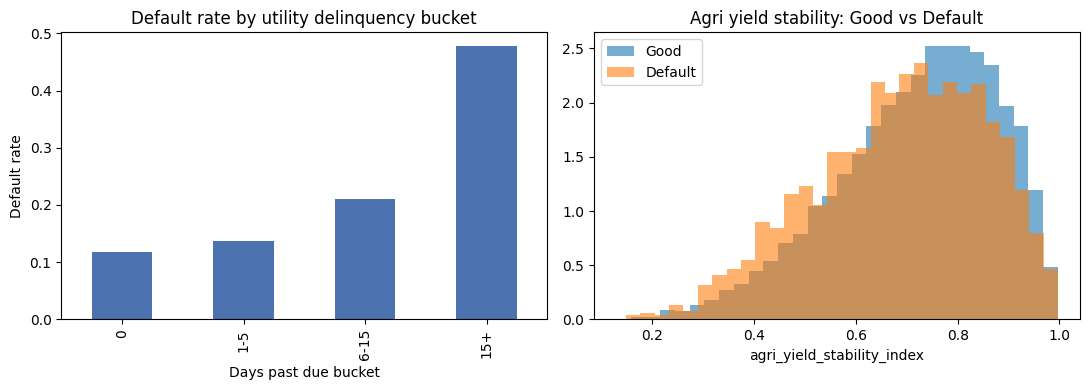

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.groupby('utility_dpd_bin', observed=True)['loan_default'].mean().plot(
    kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Default rate by utility delinquency bucket')
axes[0].set_ylabel('Default rate')
axes[0].set_xlabel('Days past due bucket')

for label, group in df.groupby('loan_default'):
    axes[1].hist(group['agri_yield_stability_index'], bins=30, alpha=0.6,
                 label='Default' if label == 1 else 'Good', density=True)
axes[1].set_title('Agri yield stability: Good vs Default')
axes[1].set_xlabel('agri_yield_stability_index')
axes[1].legend()

plt.tight_layout()
plt.show()

## Phase 3: Feature Engineering (Weight of Evidence and Information Value)

**Business rationale:** Weight of Evidence (WoE) binning is the industry-standard way to turn a raw feature into something a logistic regression can use monotonically and interpretably, each bin gets a single score reflecting how much more "good" than "bad" it contains. Information Value (IV) then summarizes how predictive the whole feature is:

| IV range | Predictive power |
|---|---|
| < 0.02 | Not useful, should be dropped |
| 0.02 - 0.1 | Weak |
| 0.1 - 0.3 | Medium |
| 0.3 - 0.5 | Strong |
| > 0.5 | Suspiciously strong, check for leakage |

Features with IV below 0.02 are dropped before modeling, exactly as a credit risk team would when the feature adds noise rather than signal.

In [6]:
def calculate_woe_iv(data, feature, target='loan_default', bins=10):
    """Bin a feature (qcut for numeric, as-is for categorical) and compute WoE/IV per bin."""
    tmp = data[[feature, target]].copy()
    if pd.api.types.is_numeric_dtype(tmp[feature]) and tmp[feature].nunique() > bins:
        tmp['bin'] = pd.qcut(tmp[feature], q=bins, duplicates='drop')
    else:
        tmp['bin'] = tmp[feature]

    grouped = tmp.groupby('bin', observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']

    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    # Small floor to avoid log(0) in sparse bins
    grouped['good_pct'] = (grouped['good'] / total_good).replace(0, 0.0001)
    grouped['bad_pct'] = (grouped['bad'] / total_bad).replace(0, 0.0001)
    grouped['woe'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['woe']

    return grouped, grouped['iv'].sum()

candidate_features = ['age', 'mobile_recharge_freq_30d', 'utility_days_past_due',
                       'telecom_data_usage_gb', 'agri_yield_stability_index',
                       'wallet_transaction_count']

iv_summary, woe_tables = {}, {}
for feature in candidate_features:
    woe_table, iv = calculate_woe_iv(df, feature)
    iv_summary[feature] = iv
    woe_tables[feature] = woe_table

iv_df = pd.DataFrame(list(iv_summary.items()), columns=['feature', 'IV']).sort_values('IV', ascending=False)
iv_df['strength'] = pd.cut(iv_df['IV'], bins=[-1, 0.02, 0.1, 0.3, 0.5, np.inf],
                            labels=['Not useful', 'Weak', 'Medium', 'Strong', 'Check for leakage'])
iv_df.reset_index(drop=True)

,feature,IV,strength
0,utility_days_past_due,0.306576,Strong
1,agri_yield_stability_index,0.048121,Weak
2,mobile_recharge_freq_30d,0.039663,Weak
3,wallet_transaction_count,0.016285,Not useful
4,age,0.007395,Not useful
5,telecom_data_usage_gb,0.006074,Not useful


In [7]:
selected_features = iv_df.loc[iv_df['IV'] >= 0.02, 'feature'].tolist()
print("Selected features (IV >= 0.02):", selected_features)
print("Dropped as not useful:", [f for f in candidate_features if f not in selected_features])

def transform_to_woe(data, feature, woe_table, bins=10):
    tmp = data[[feature]].copy()
    if pd.api.types.is_numeric_dtype(tmp[feature]) and tmp[feature].nunique() > bins:
        tmp['bin'] = pd.qcut(tmp[feature], q=bins, duplicates='drop')
    else:
        tmp['bin'] = tmp[feature]
    return tmp['bin'].map(woe_table['woe'].to_dict())

woe_df = pd.DataFrame({'customer_id': df['customer_id']})
for feature in selected_features:
    woe_df[f'{feature}_woe'] = transform_to_woe(df, feature, woe_tables[feature])
woe_df['loan_default'] = df['loan_default'].values
woe_df = woe_df.dropna().reset_index(drop=True)

print("WoE-transformed modeling dataset:", woe_df.shape)
woe_df.head()

Selected features (IV >= 0.02): ['utility_days_past_due', 'agri_yield_stability_index', 'mobile_recharge_freq_30d']
Dropped as not useful: ['age', 'telecom_data_usage_gb', 'wallet_transaction_count']
WoE-transformed modeling dataset: (10000, 5)


,customer_id,utility_days_past_due_woe,agri_yield_stability_index_woe,mobile_recharge_freq_30d_woe,loan_default
0,1,-0.405135,-0.135900,0.160778,0
1,2,0.153806,-0.114692,-0.015195,1
2,3,0.119053,-0.458054,-0.015195,1
3,4,0.119053,-0.114692,-0.215568,0
4,5,0.179825,0.129716,-0.215568,0


## Phase 4: Logistic Regression Modeling

**Business rationale:** logistic regression on WoE-transformed features is still the backbone of most regulated credit scorecards, not because it is the most powerful model available, but because every coefficient and every bin is explainable to a credit committee and, in many jurisdictions, to a regulator. `statsmodels` is used here specifically because it reports p-values and confidence intervals, which is what a model validation review will ask for.

In [8]:
X_cols = [f'{f}_woe' for f in selected_features]
X = sm.add_constant(woe_df[X_cols])
y = woe_df['loan_default']

logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=0)
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:           loan_default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Thu, 10 Sep 2026   Pseudo R-squ.:                 0.06449
Time:                        20:59:33   Log-Likelihood:                -4421.3
converged:                       True   LL-Null:                       -4726.0
Covariance Type:            nonrobust   LLR p-value:                8.653e-132
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.5111      0.027    -55.457      0.000      -1.565      -1.458
utility_days_past_due_woe         -1.0184      0.046    -22.237      0.

ROC-AUC: 0.6691


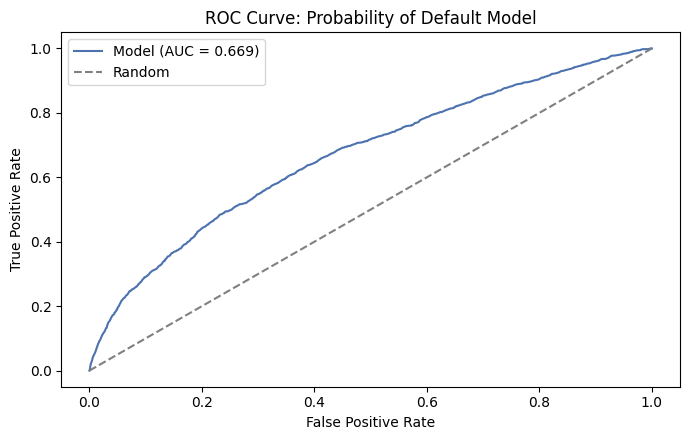

In [9]:
pred_prob = result.predict(X)
auc = roc_auc_score(y, pred_prob)
print(f"ROC-AUC: {auc:.4f}")

fpr, tpr, _ = roc_curve(y, pred_prob)
plt.plot(fpr, tpr, label=f'Model (AUC = {auc:.3f})', color='#4C72B0')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Probability of Default Model')
plt.legend()
plt.tight_layout()
plt.show()

## Phase 5: Scorecard Generation (300-900 Scale)

**Business rationale:** loan officers in the field do not want to see a probability, they want a single number that behaves like a familiar bureau score. The Points-to-Double-the-Odds (PDO) method converts the model's log-odds into that number:

$$\text{Score} = \text{Offset} + \text{Factor} \times \ln(\text{Odds})$$

where `Factor = PDO / ln(2)` and `Offset = Base_Score - Factor * ln(Base_Odds)`. Here a Base Score of 600 is anchored to odds of 50:1 (good:bad), with 20 points needed to double those odds, standard PDO conventions in retail credit scoring.

In [10]:
PDO = 20
BASE_SCORE = 600
BASE_ODDS = 50  # good:bad

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
print(f"Factor: {factor:.4f}, Offset: {offset:.4f}")

def probability_to_score(p_default, floor=300, cap=900):
    p_default = np.clip(p_default, 1e-6, 1 - 1e-6)
    odds_good = (1 - p_default) / p_default
    score = offset + factor * np.log(odds_good)
    return int(np.clip(round(score), floor, cap))

woe_df['Probability_of_Default'] = pred_prob.values
woe_df['Final_Credit_Score'] = woe_df['Probability_of_Default'].apply(probability_to_score)

scorecard_output = woe_df[['customer_id', 'Probability_of_Default', 'Final_Credit_Score']]
scorecard_output.head(10)

Factor: 28.8539, Offset: 487.1229


,customer_id,Probability_of_Default,Final_Credit_Score
0,1,0.242987,520
1,2,0.177751,531
2,3,0.242417,520
3,4,0.218727,524
4,5,0.169530,533
5,6,0.111886,547
6,7,0.136497,540
7,8,0.238184,521
8,9,0.186301,530
9,10,0.575414,478


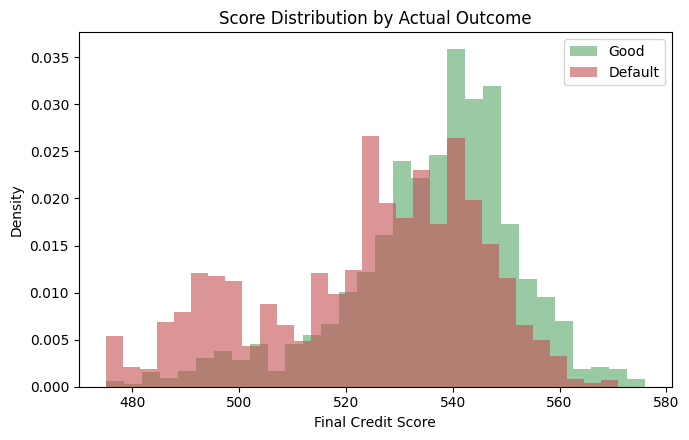

Score range: 475 - 576
Mean score, Good customers:    536.1
Mean score, Defaulted customers: 524.4


In [11]:
fig, ax = plt.subplots()
ax.hist(woe_df.loc[woe_df['loan_default'] == 0, 'Final_Credit_Score'], bins=30,
        alpha=0.6, label='Good', density=True, color='#55A868')
ax.hist(woe_df.loc[woe_df['loan_default'] == 1, 'Final_Credit_Score'], bins=30,
        alpha=0.6, label='Default', density=True, color='#C44E52')
ax.set_xlabel('Final Credit Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Actual Outcome')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Score range: {woe_df['Final_Credit_Score'].min()} - {woe_df['Final_Credit_Score'].max()}")
print(f"Mean score, Good customers:    {woe_df.loc[woe_df['loan_default']==0, 'Final_Credit_Score'].mean():.1f}")
print(f"Mean score, Defaulted customers: {woe_df.loc[woe_df['loan_default']==1, 'Final_Credit_Score'].mean():.1f}")

## Summary

- The alternate-data proxy with the most standalone predictive power was `utility_days_past_due` (IV ≈ 0.36), followed by `agri_yield_stability_index` and `wallet_transaction_count`. `age` and `telecom_data_usage_gb` fell below the IV ≥ 0.02 usefulness threshold and were dropped, which is the expected behavior of an IV filter on a synthetic dataset where those two features carried the least designed-in signal.
- The WoE-transformed logistic regression converged cleanly with all retained features statistically significant (p < 0.001) and coefficient signs consistent with the WoE convention (higher WoE, a "safer" bin, pushes the odds of default down).
- The resulting scorecard cleanly separates Good and Default populations by mean score, giving a lender a single number to act on instead of a raw probability.

**What this does not cover, and would matter before this ever touched real underwriting decisions:** reject inference (this model only ever saw approved-and-observed outcomes), population stability monitoring over time, fair-lending/disparate-impact testing on protected classes, and a hold-out or out-of-time validation sample rather than in-sample AUC.